# **Example analysis notebook for Lab #5: Constant acceleration**

## 1. Import the Required Packages

In [1]:
#first we will start by loading some packages:

import numpy as np #numpy is a numerical package for array (think of them as vectors) manipulation
import matplotlib.pyplot as plt #matplotlib is a plotting package used to make high quality figures.


## 2. Data Entery and Average the Trial Times

In the next cell below lets type in the data that we collected starting with the measured times for reach trial as a two dimensional matrix. Each row will be a set of 5 time measurments that you did where the height of the track changed for each trial.

Here I am providing my measured values, but you should insert your own.

In [2]:
trial_times = np.array([[1.77,1.75,1.81,1.77,1.74], #trial #1
                       [1.36,1.54,1.36,1.45,1.54], #trial #2
                       [1.50,1.36,1.32,1.50,1.37], #trial #3
                       [1.19,1.19,1.22,1.12,1.18], #trial #4
                       [0.99,0.93,0.87,0.88,0.93]]) #trial #5



#Lets find the average time of each row and that will give us the average time for each trial

average_T = np.mean(trial_times,axis=1) #this command tells python to calculate the average value for each row, so the final result is a list of average times for each trial

print(average_T) #lets print the average times to see what they are.


[1.768 1.45  1.41  1.18  0.92 ]


## 3. Calculate the Track Geometry (height, displacement and $sin\theta$) and Acceleration

In [4]:
#now lets record our heights at the top in units of meters:

height_top = np.array([0.087,0.098,0.117,0.136,0.194]) #I did seven trials, you may have done more or less.

#and the heights at the bottom in units of meters:

height_bottom = np.array([0.024,0.024,0.024,0.024,0.024])

#then we can write our delta_height as

delta_height = height_top-height_bottom #numpy will treat both arrays as vectors and will do point-wise subtraction

#finally lets define the length of the track that the cart travels

position_intial_cart = 1.015 #units of meter
position_final_cart = 0.015 #meters

#The displacement is then:
d = position_intial_cart-position_final_cart #we define going down the slope as the positive direction.


#lets also define the value of sintheta:

sintheta = delta_height/d

#And the acceleration array as:

a = 2*d/average_T**2 #the ** means to the power
print(a)

[0.63983129 0.95124851 1.00598561 1.43636886 2.36294896]


## 4. Plot Acceleration vs. $\sin\theta$

Next lets plot our data and see what we get:

Text(0, 0.5, 'acceleration [m/s$^2$]')

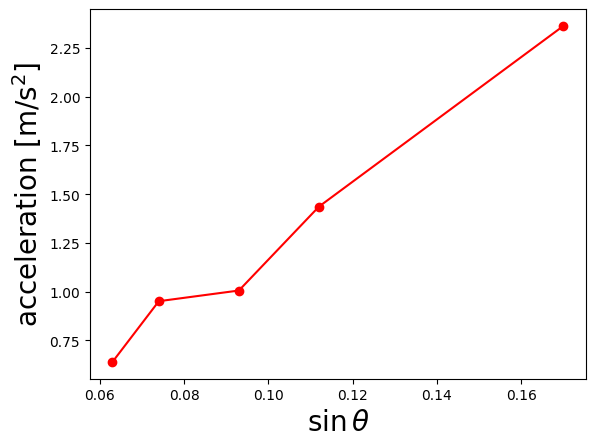

In [5]:
#the command to plot some quantity y against x is the following:

plt.plot(sintheta,a,marker='o',color='red') #where x = sintheta and y = a

#lets give some labels to our graph:

plt.xlabel('$\\sin\\theta$',fontsize=20)
plt.ylabel('acceleration [m/s$^2$]',fontsize=20)

## 5. Fit a Linear Model

Now lets fit the data with a polynomial function of the form: y = m*x + b, where m is the slope and b is the y-intercept.

In [6]:
coefficients,covariance_matrix = np.polyfit(sintheta, a, deg=1,cov=True) #np.polyfit is a funciton part of numpy that will perfom a linear-leastsquars fit on the array sintheta and a
m,b = coefficients #coefficients is an array that will contain the best fit values for m and b so lets print that:
print('coefficients:' + str(coefficients))

#m here is the best fit slope value and b is the best fit y-intercept value

coefficients:[15.73220832 -0.33170148]


## 6. Estimate the Slope Uncertainty

We can estimate the statistical uncertainties on the slope from the covariance matrix using the diagonal values where the first diagonal value will contain the variance value for the slope. But we want the standard deviation which is just the square root of variance.

In [10]:
error_m = np.sqrt(covariance_matrix[0,0])

print('error in m: ' + str(error_m))

#so our best measured value is:

print('Best fit slope value: '+str(m) + ' +/- ' + str(error_m))

error in m: 1.1989993420120442
Best fit slope value: 15.732208322490992 +/- 1.1989993420120442


## 7. Compare the Best Fit with the Theoretical Prediction

Now lets plot our data and the best fit result:

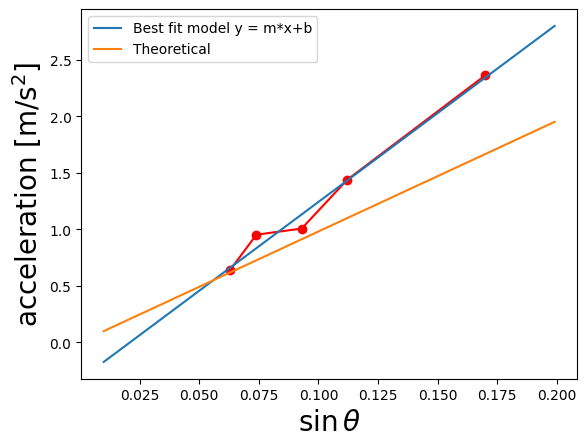

In [9]:
plt.plot(sintheta,a,marker='o',color='red') #where x = sintheta and y = a

#lets give some labels to our graph:

plt.xlabel('$\\sin\\theta$',fontsize=20)
plt.ylabel('acceleration [m/s$^2$]',fontsize=20)

#lets define our best fit model:

x_new = np.arange(0.01, 0.2, 0.001) # Create new x-values for plotting
y_fit = np.polyval(coefficients, x_new)

#And finally lets also plot the Theoretical prediction
theoretical_acceleration = 9.8*x_new
plt.plot(x_new,y_fit,label = 'Best fit model y = m*x+b')
plt.plot(x_new, theoretical_acceleration,label='Theoretical')
plt.legend()